# Assignment 3 Visualization code

In [2]:

# source: https://open.toronto.ca/dataset/daily-shelter-overnight-service-occupancy-capacity
# libraries and packages

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import PIL
import requests


In [3]:
# get data from API

# connect to API
url = "https://ckan0.cf.opendata.inter.prod-toronto.ca/api/3/action/package_show"
params = {
    "id": "daily-shelter-overnight-service-occupancy-capacity"
}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    # Get the URL of the actual CSV resource in the dataset
    resource_url = data['result']['resources'][0]['url']
    print("Downloading from:", resource_url)

    # Load CSV into DataFrame
    import pandas as pd
    df = pd.read_csv(resource_url)
    print(df.head())
else:
    print("API request failed:", response.status_code)




   _id OCCUPANCY_DATE  ORGANIZATION_ID         ORGANIZATION_NAME  SHELTER_ID  \
0    1     2025-01-01               24  COSTI Immigrant Services          40   
1    2     2025-01-01               24  COSTI Immigrant Services          40   
2    3     2025-01-01               24  COSTI Immigrant Services          40   
3    4     2025-01-01               24  COSTI Immigrant Services          40   
4    5     2025-01-01               24  COSTI Immigrant Services          40   

            SHELTER_GROUP  LOCATION_ID               LOCATION_NAME  \
0  COSTI Reception Centre         1320   COSTI Hotel Program Dixon   
1  COSTI Reception Centre         1320   COSTI Hotel Program Dixon   
2  COSTI Reception Centre         1051      COSTI Reception Centre   
3  COSTI Reception Centre         1051      COSTI Reception Centre   
4  COSTI Reception Centre         1114  COSTI Uptown Hotel Program   

    LOCATION_ADDRESS LOCATION_POSTAL_CODE  ... OCCUPIED_BEDS UNOCCUPIED_BEDS  \
0      640 Dixon R

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27695 entries, 0 to 27694
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   _id                     27695 non-null  int64  
 1   OCCUPANCY_DATE          27695 non-null  object 
 2   ORGANIZATION_ID         27695 non-null  int64  
 3   ORGANIZATION_NAME       27695 non-null  object 
 4   SHELTER_ID              27695 non-null  int64  
 5   SHELTER_GROUP           27695 non-null  object 
 6   LOCATION_ID             27695 non-null  int64  
 7   LOCATION_NAME           27695 non-null  object 
 8   LOCATION_ADDRESS        26447 non-null  object 
 9   LOCATION_POSTAL_CODE    26447 non-null  object 
 10  LOCATION_CITY           26436 non-null  object 
 11  LOCATION_PROVINCE       26310 non-null  object 
 12  PROGRAM_ID              27695 non-null  int64  
 13  PROGRAM_NAME            27695 non-null  object 
 14  SECTOR                  27695 non-null

In [5]:
# select needed data

selected_columns = ['ORGANIZATION_NAME', 'LOCATION_NAME', 'SECTOR', 'PROGRAM_AREA', 'SERVICE_USER_COUNT']

df_clean = df[selected_columns]

df_clean

,ORGANIZATION_NAME,LOCATION_NAME,SECTOR,PROGRAM_AREA,SERVICE_USER_COUNT
0,COSTI Immigrant Services,COSTI Hotel Program Dixon,Families,Temporary Refugee Response,658
1,COSTI Immigrant Services,COSTI Hotel Program Dixon,Mixed Adult,Temporary Refugee Response,113
2,COSTI Immigrant Services,COSTI Reception Centre,Mixed Adult,Base Program - Refugee,8
3,COSTI Immigrant Services,COSTI Reception Centre,Mixed Adult,Base Program - Refugee,8
4,COSTI Immigrant Services,COSTI Uptown Hotel Program,Families,Temporary Programs,215
...,...,...,...,...,...
27690,Youth Without Shelter,Youth Without Shelter,Youth,Base Shelter and Overnight Services System,33
27691,Youth Without Shelter,Youth Without Shelter,Youth,Base Shelter and Overnight Services System,20
27692,YouthLink,YouthLink,Youth,Base Shelter and Overnight Services System,10
27693,YouthLink,YouthLink,Youth,Winter Programs,1


In [6]:
# summarizeb by sector and program

summarized_df = df_clean.groupby(['SECTOR', 'PROGRAM_AREA'])['SERVICE_USER_COUNT'].sum().reset_index()

summarized_df


,SECTOR,PROGRAM_AREA,SERVICE_USER_COUNT
0,Families,Base Program - Refugee,74214
1,Families,Base Shelter and Overnight Services System,133159
2,Families,Temporary Programs,48274
3,Families,Temporary Refugee Response,240888
4,Men,Base Shelter and Overnight Services System,281105
5,Men,Temporary Programs,78501
6,Men,Temporary Refugee Response,52497
7,Men,Winter Programs,18212
8,Mixed Adult,Base Program - Refugee,22576
9,Mixed Adult,Base Shelter and Overnight Services System,178165


In [7]:
# pivot table
shelter_pivot = (summarized_df.pivot(index= 'PROGRAM_AREA', columns= 'SECTOR', values= 'SERVICE_USER_COUNT'))


<Figure size 640x480 with 0 Axes>

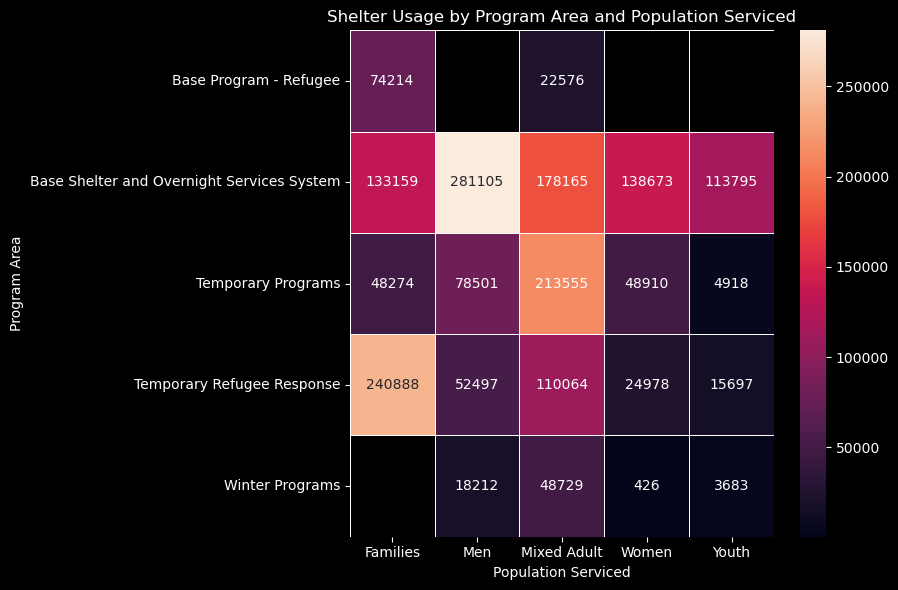

In [9]:
# set dark mode

plt.style.use('dark_background')
plt.tight_layout()

# create a heatmap

figure, ax = plt.subplots(figsize= (9,6))
sheltergraph = sns.heatmap(shelter_pivot, 
            annot=True,
            fmt='.0f', 
            linewidths=0.5, 
            ax=ax)

# format and add labels
sheltergraph.set(title= 'Shelter Usage by Program Area and Population Serviced',
                 xlabel= 'Population Serviced',
                 ylabel= 'Program Area')

plt.tight_layout()

# saving plot as PNG file
plt.savefig('shelter_usage_heatmap.png')